# FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

### Part 1: Data Preparation and Exploration

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('exchange_rate.csv')

# Fix datetime format
df.iloc[:, 0] = pd.to_datetime(df.iloc[:, 0], dayfirst=True)

# Set index
df.set_index(df.columns[0], inplace=True)

df.columns = ['Exchange_Rate']

df.head()

,Exchange_Rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


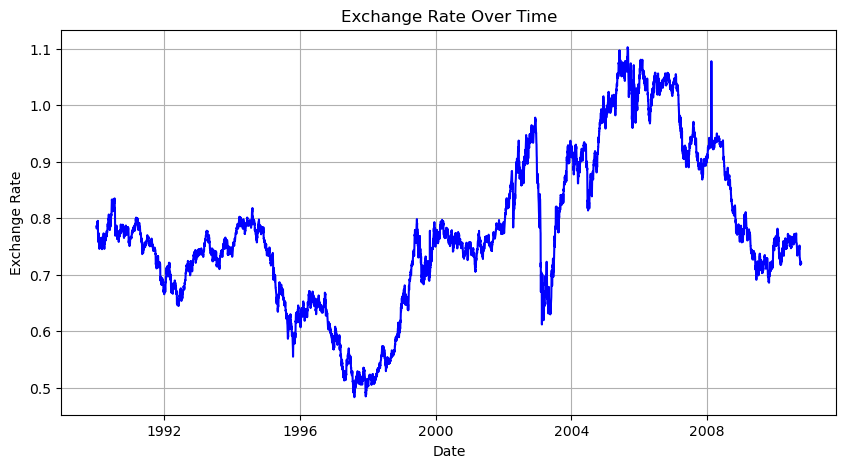

In [2]:
import matplotlib.pyplot as plt

# Plot time series
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Exchange_Rate'], color='blue')

plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')

plt.grid(True)
plt.show()

In [3]:
# Check missing values
df.isnull().sum()

# Fill missing values using forward fill
df = df.fillna(method='ffill')

In [4]:
df.isnull().sum()

Exchange_Rate    0
dtype: int64

### 3 Part 2: Model Building - ARIMA

p-value: 0.44923273535982894


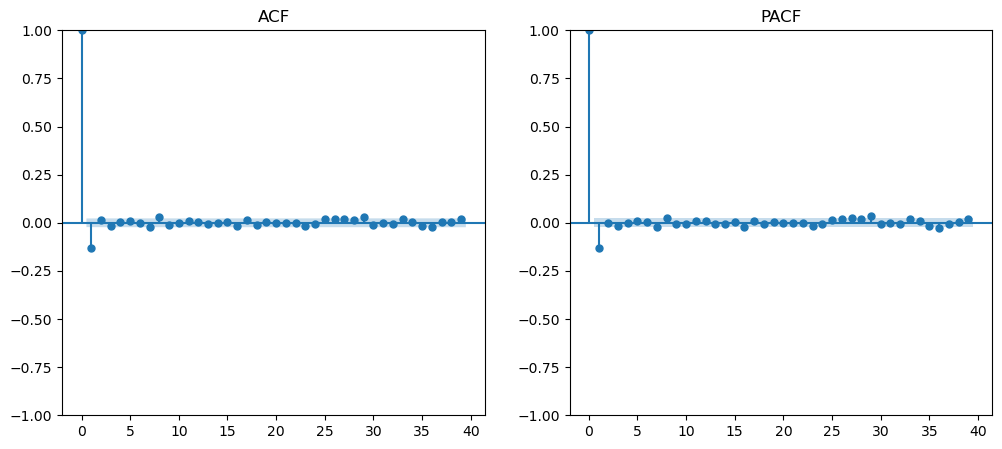

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Check stationarity
result = adfuller(df['Exchange_Rate'])
print("p-value:", result[1])

# Differencing if needed
df_diff = df['Exchange_Rate'].diff().dropna()

# ACF & PACF
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df_diff, ax=plt.gca())
plt.title("ACF")

plt.subplot(1,2,2)
plot_pacf(df_diff, ax=plt.gca())
plt.title("PACF")

plt.show()

In [6]:
p, d, q = 1, 1, 1   # example

In [14]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')
# Train-test split
train_size = int(len(df) * 0.8)
train = df['Exchange_Rate'][:train_size]
test = df['Exchange_Rate'][train_size:]

# Fit model
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:          Exchange_Rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Tue, 07 Apr 2026   AIC                         -45432.092
Time:                        12:59:15   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

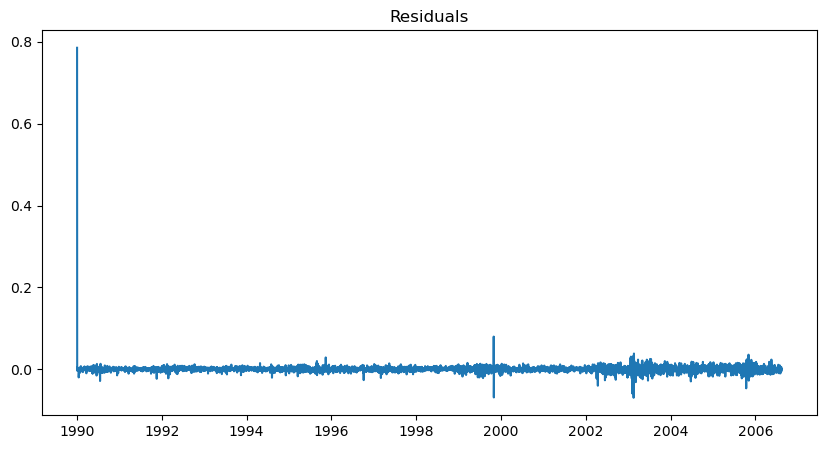

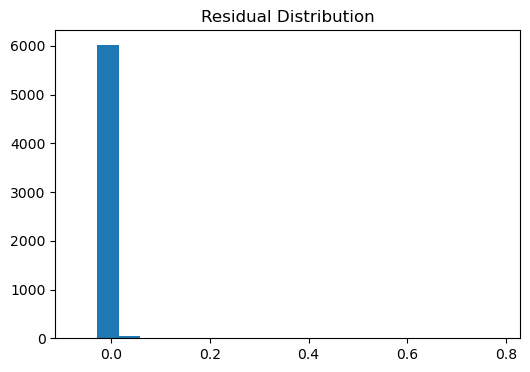

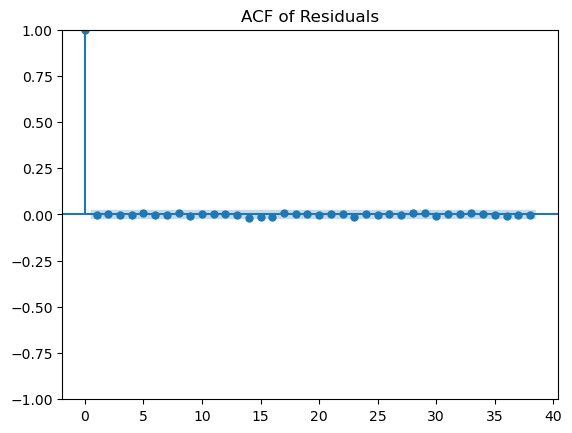

In [8]:
residuals = model_fit.resid

# Plot residuals
plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

# Histogram
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.show()

# ACF of residuals
plot_acf(residuals)
plt.title("ACF of Residuals")
plt.show()

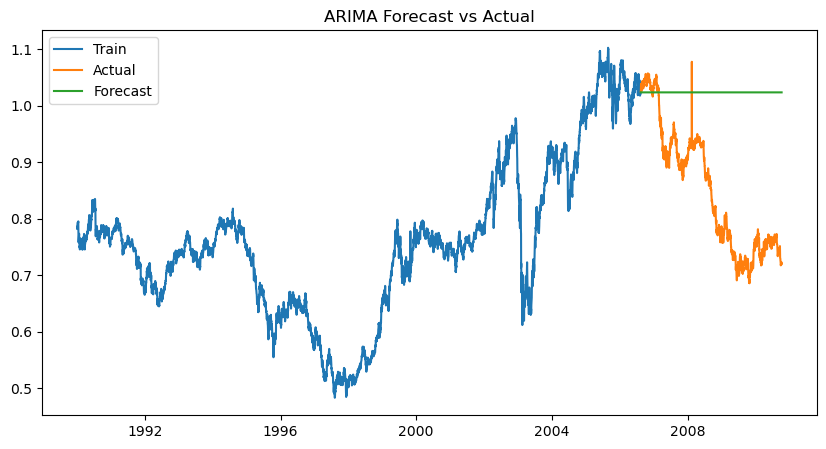

In [9]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot results
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

### Part 3: Evaluation and Comparison


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
# Build model
exp_model = ExponentialSmoothing(train, trend='add', seasonal=None)

# Fit model
exp_fit = exp_model.fit()

# Forecast
exp_forecast = exp_fit.forecast(steps=len(test))

In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Function for metrics
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

# ARIMA metrics
arima_mae, arima_rmse, arima_mape = evaluate(test, forecast)

# Exponential Smoothing metrics
exp_mae, exp_rmse, exp_mape = evaluate(test, exp_forecast)

print("ARIMA Results:")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

print("\nExponential Smoothing Results:")
print("MAE:", exp_mae)
print("RMSE:", exp_rmse)
print("MAPE:", exp_mape)

ARIMA Results:
MAE: 0.1777097044912133
RMSE: 0.20543669659669261
MAPE: 22.79796617381153

Exponential Smoothing Results:
MAE: 0.19027449606489796
RMSE: 0.22008638668287628
MAPE: 24.41283524089983
